In [1]:
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')  
gpus = tf.config.list_physical_devices('GPU')

from utils import encode_labels, perform_patient_split, get_class_weights, plot_confusion_matrix
import pandas as pd
df = pd.read_csv("../features-extraction/features-relative.csv")

train_mask, test_mask, y_train, y_test = perform_patient_split(df)

drop_cols = ['Start', 'End', 'file', 'Start Sample', 'End Sample', 'Label']

X = df.drop(drop_cols, axis=1).values

X_train = X[train_mask]
X_test  = X[test_mask]

y_train, y_test, labels = encode_labels(y_train, y_test)



2025-12-18 07:42:53.687576: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-18 07:42:53.757344: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

from sklearn.ensemble import RandomForestClassifier


class_weights = get_class_weights(y_train)
rfc = RandomForestClassifier(random_state=0, n_estimators=300, class_weight=get_class_weights(y_train))

rfc.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Figure size 600x500 with 0 Axes>

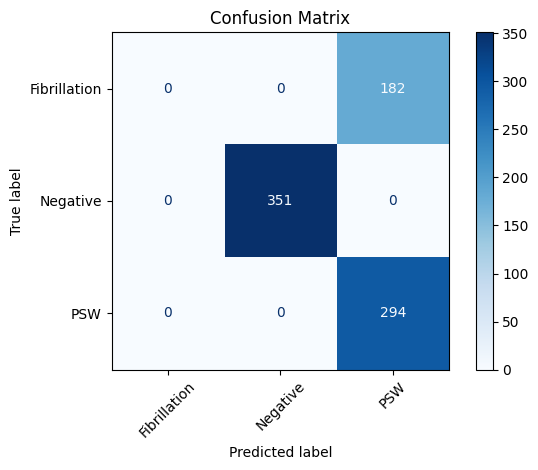


Classification Report:
              precision    recall  f1-score   support

Fibrillation       0.00      0.00      0.00       182
    Negative       1.00      1.00      1.00       351
         PSW       0.62      1.00      0.76       294

    accuracy                           0.78       827
   macro avg       0.54      0.67      0.59       827
weighted avg       0.64      0.78      0.70       827



In [3]:
y_pred = rfc.predict(X_test)

plot_confusion_matrix(y_test,y_pred, labels)

In [4]:

feature_scores = pd.Series(rfc.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print(feature_scores)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

Accuracy with normal split 0.89 accuracy
with patient split 0.78